In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from scipy.linalg import lstsq

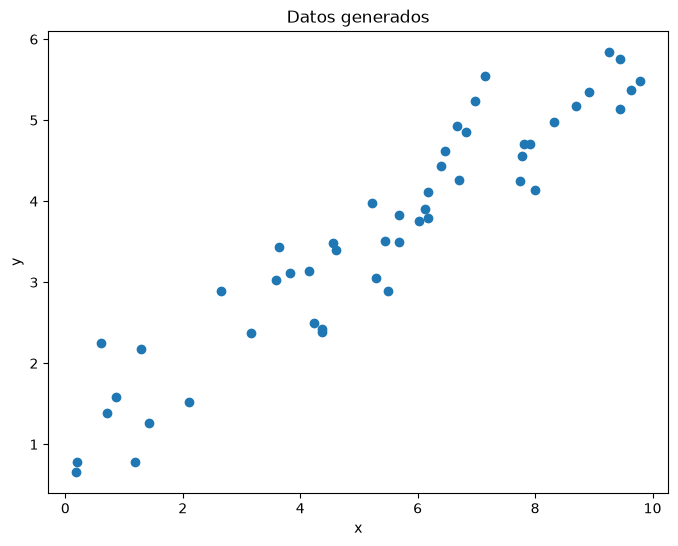

In [2]:
# Generamos datos para la recta de "regresion"
np.random.seed(0)
x = np.random.uniform(0, 10, 50)
noise = np.random.normal(0, 0.5, 50)
y = 1 + 0.5*x + noise

datos = list(zip(x, y))

plt.figure(figsize=(8, 6))
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Datos generados')
plt.show()

In [3]:
#FITTING THE DATA BY THE LEAST LINEAR DISTANCE
x_arr = np.asarray(x)
y_arr = np.asarray(y)

alpha = cp.Variable()
beta = cp.Variable()
e = cp.Variable(len(datos), nonneg=True)

constraints = [
    e >= -(alpha + beta*x_arr - y_arr),
    e >=   alpha + beta*x_arr - y_arr,
]
objective = cp.Minimize(cp.sum(e))
prob = cp.Problem(objective, constraints)
prob.solve()

np.float64(18.606736828360823)

In [4]:
# solo es preparacion para la grafica
a_l1 = alpha.value
b_l1 = beta.value
rectaAjuste = [(0, a_l1), (10, a_l1 + 10*b_l1)]

In [5]:
## LEAST SQUARE METHOD
A = np.column_stack([np.ones(len(x_arr)), x_arr])
params, *_ = lstsq(A, y_arr)
amin, bmin = params
rectaMinCuadrados = [(0, amin), (10, amin + 10*bmin)]

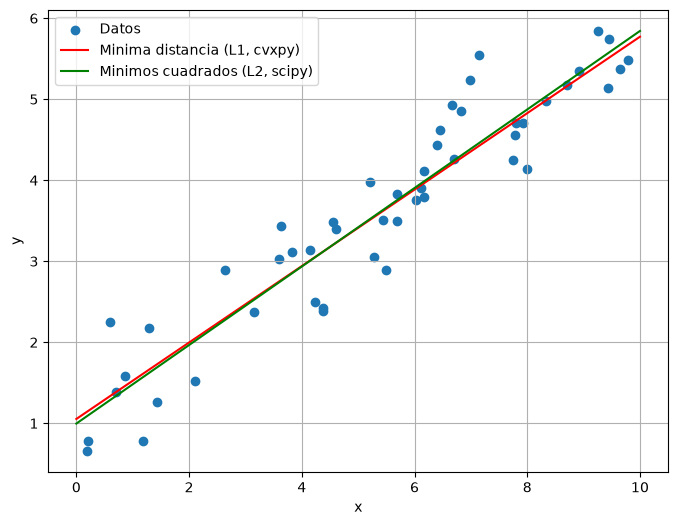

In [6]:
## GRAPH ALL THE DATA
##    THE GREEN LINE IS THE DATA ADJUSTED BY THE LEAST SQUARE METHOD
##    THE RED LINE REPRESENTS THE MINIMUM DISTANCES TO THE ABSOLUTE VALUE METHOD
plt.figure(figsize=(8, 6))
plt.scatter(x_arr, y_arr, label='Datos')
xx = np.array([0.0, 10.0])
plt.plot(xx, a_l1 + b_l1*xx, 'r-', label='Minima distancia (L1, cvxpy)')
plt.plot(xx, amin + bmin*xx, 'g-', label='Minimos cuadrados (L2, scipy)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()